# Efficient Polynomial Evaluations

## Purpose:
The objective of this report is to evaluate the efficiency of three algorithms for evaluating polynomials of the form:

$$
P_n(x) = 1 + x + 2x^{2} + \dots + nx^{n}
$$

The algorithms to be tested are:
- **Brute Force Algorithm (B.F.)**
- **Horner's Algorithm (H.A.)**
- **Repeated Squaring Algorithm (R.S.)**

The evaluation will focus on the efficiency of these algorithms, with performance measured in milliseconds.

## Methodology:

### Measuring Runtime
To measure the efficiency of each algorithm, execution times were recorded using the `time.time()` method * 1000 to obtain the time in milliseconds. These times were then used to compare the performance of the three algorithms.

### Simulating Overflow

The range for a signed integer \( x \) is \( -2^{31} - 2 < x < 2^{31} \). To simulate overflow, the function begins with a starting value and computes:

$$
(\text{starting value} \mod (2^{31} - 1)) + (-2^{31} - 1)
$$

This process continues until the resulting value flows into the negative range, thus simulating the behavior you would expect when exceeding the maximum value for an signed integer. 


### Setup

In [1]:
import IPython.core.display
from IPython.core.display import HTML
display(HTML("<style>div.output_area pre {white-space: pre; overflow-x: auto;}</style>"))


In [2]:

from polynomials import *
from testing_tools import *
from decimal import Decimal
import random
random.seed(349)

## Experiment 1 - Observing Overflow
### Purpoe
The purpose of this round of testing is to witness the issue of *integer overflow* in each algorithm, B.F., H.A. and R.S. 


### Setup

In [3]:
# Generate ten test cases, with x and n being between 20 and 40
ex1_test_cases = create_test_cases(10,20,40)
# Calculate values,get times for each algorithm
ex1_brute_force = generate_results(brute_force,ex1_test_cases)
ex1_horners_rule = generate_results(horners_rule,ex1_test_cases)
ex1_repeated_squaring = generate_results(repeated_squaring,ex1_test_cases)
# gets overflow values, appends them to seperate lists
of_bf = []
of_hr = []
of_rs = []

for i in ex1_brute_force.index:
    of_bf.append(trigger_overflow(i))
for i in ex1_horners_rule.index:
    of_hr.append(trigger_overflow(i))
for i in ex1_repeated_squaring.index:
    of_rs.append(trigger_overflow(i))
# add lists to dataframes
ex1_brute_force['overflow_value']= of_bf
ex1_horners_rule['overflow_value']= of_hr
ex1_repeated_squaring['overflow_value']=of_rs

### Results

In [4]:
ex1_brute_force

,x,n,time_ms,overflow_value
value,,,,
26128640051322339214200517265441,32,20,0.042439,-1101672116
1996741937554908233595081063731197333,33,23,0.065088,-1181803871
2309109693578016554561650587452782526,25,25,0.079155,-2140227056
80101755682854128724854833138522610863767,38,25,0.048876,-1899782934
2780360792608500523066841317478021263919035,33,27,0.076771,-489754519
3258809607248249672869186600707141409626811,26,29,0.089169,-1356372749
40238805592353902734050921420158437930666017,32,28,0.073671,-2074083328
6382380277892389334126040428061831153388822831,30,30,0.058651,-1273913505
197861133125915959334126040428061831153388822831,30,31,0.097513,-210390963


In [5]:
ex1_horners_rule

,x,n,time_ms,overflow_value
value,,,,
26128640051322339214200517265441,32,20,0.01502,-1101672116
1996741937554908233595081063731197333,33,23,0.016212,-1181803871
2309109693578016554561650587452782526,25,25,0.018835,-2140227056
80101755682854128724854833138522610863767,38,25,0.016928,-1899782934
2780360792608500523066841317478021263919035,33,27,0.025511,-489754519
3258809607248249672869186600707141409626811,26,29,0.030518,-1356372749
40238805592353902734050921420158437930666017,32,28,0.026941,-2074083328
6382380277892389334126040428061831153388822831,30,30,0.017166,-1273913505
197861133125915959334126040428061831153388822831,30,31,0.020504,-210390963


In [6]:
ex1_repeated_squaring

,x,n,time_ms,overflow_value
value,,,,
26128640051322339214200517265441,32,20,0.03767,-1101672116
1996741937554908233595081063731197333,33,23,0.048876,-1181803871
2309109693578016554561650587452782526,25,25,0.06485,-2140227056
80101755682854128724854833138522610863767,38,25,0.045776,-1899782934
2780360792608500523066841317478021263919035,33,27,0.050783,-489754519
3258809607248249672869186600707141409626811,26,29,0.051975,-1356372749
40238805592353902734050921420158437930666017,32,28,0.053167,-2074083328
6382380277892389334126040428061831153388822831,30,30,0.053406,-1273913505
197861133125915959334126040428061831153388822831,30,31,0.058889,-210390963


### Findings
In round one, 
* *Brute Force Algorithm*, 
* *Horner's Algorithm* ,
* *Repeated Squaring Algorithm*,\
\
were each tested within a large range:
$$\begin{aligned}
x,n \in [20,40] \\
s.t.\\
value > 2^{31}-1\text{ or }2147483647 \\
\end{aligned}$$

Integer Overflow was successfully triggered in each case. 

## Experiment 2 - Small Value Tests

### Purpose:
The purpose of this round is to test each algorithm on small values to evaluate their accuracy. Based on the results from the previous round—where the value lengths matched and the first and last digits were consistent, it is highly likely that the algorithms are functioning correctly.

### Preliminary Observations:
Given the positive outcome from the previous tests, it is reasonable to assume that the algorithms are working as intended. However, this round will serve to further confirm their accuracy with small input values.

### Setup

In [7]:
# Generate thirty test cases, with x and n being between 2 and 25
ex2_test_cases = create_test_cases(100,2,25)
# Calculate values,get times for each algorithm
ex2_brute_force = generate_results(brute_force,ex2_test_cases)
ex2_horners_rule = generate_results(horners_rule,ex2_test_cases)
ex2_repeated_squaring = generate_results(repeated_squaring,ex2_test_cases)

### Results

In [8]:
ex2_brute_force.head(10)

,x,n,time_ms
value,,,
35,2,3,0.015736
211,10,2,0.01955
229,4,3,0.022173
352,13,2,0.020504
427,3,4,0.01359
431,5,3,0.017166
466,15,2,0.013351
529,16,2,0.011683
821,20,2,0.012875


In [9]:
ex2_horners_rule.head(10)

,x,n,time_ms
value,,,
35,2,3,0.012398
211,10,2,0.012875
229,4,3,0.013351
352,13,2,0.02718
427,3,4,0.011444
431,5,3,0.012159
466,15,2,0.011683
529,16,2,0.011683
821,20,2,0.017166


In [10]:
ex2_repeated_squaring.head(10)

,x,n,time_ms
value,,,
35,2,3,0.025988
211,10,2,0.016928
229,4,3,0.016451
352,13,2,0.013113
427,3,4,0.017166
431,5,3,0.020742
466,15,2,0.02408
529,16,2,0.023603
821,20,2,0.016928


In [11]:
ex2_values = pd.DataFrame({
    "Brute_Force": ex2_brute_force.index.tolist(),
    "Horners_Algo": ex2_horners_rule.index.tolist(),
    "Repeated_Sq": ex2_repeated_squaring.index.tolist()
})

In [12]:
ex2_values.head(10)

,Brute_Force,Horners_Algo,Repeated_Sq
0,35,35,35
1,211,211,211
2,229,229,229
3,352,352,352
4,427,427,427
5,431,431,431
6,466,466,466
7,529,529,529
8,821,821,821
9,1135,1135,1135


### Visualization

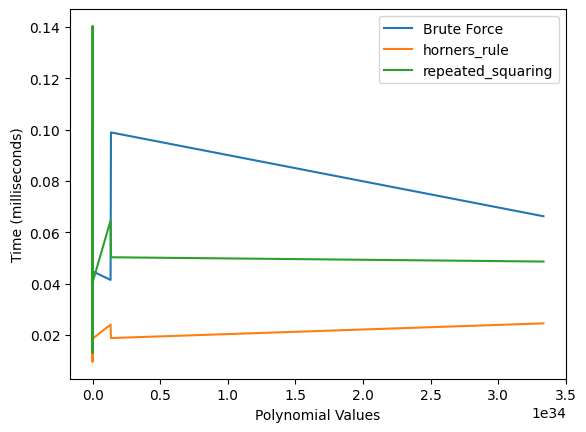

In [13]:
plt.plot(ex2_brute_force.index,ex2_brute_force['time_ms'],label='Brute Force')
plt.plot(ex2_horners_rule.index,ex2_horners_rule['time_ms'],label='horners_rule')
plt.plot(ex2_repeated_squaring.index,ex2_repeated_squaring['time_ms'],label='repeated_squaring')
plt.xlabel("Polynomial Values")
plt.ylabel("Time (milliseconds)")
plt.legend()
plt.show()

### Findings
The functions are working as expected, each outputting the same values. It is interesting to witness that even at small values for x and n, 2 < x,n < 25, we are witnessing that the most efficient algorithm is **H.R.** while the least efficient is **B.F.**. 

#### Number of Multiplications

**Brute Force: $5n^2 +6n$**\
\
**Repeated Squaring: $~n*log_{2}n$** because the number of multiplications to get each term is:$2^k = log_{2}k$, and this is done n times.\
\
**Horners Rule: $n$**
#### Conclusion
The times recorded in the visualization follow what I would expect. 
Using L'hopital's Rule, we can show that the growth factor for Horner's Rule is slower than both other techniques.
\
\
**Comparing to Repeated Squaring** \
\
$\lim_{n \to \infty} \frac{n \log n}{n} = \lim_{n \to \infty} \frac{n\ln{n}}{ln{2}} = \infty$\
\
**Comparing to Brute Force**\
\
$\lim_{n \to \infty} \frac{5n^2 + 6n}{n} = \lim_{n \to \infty} \frac{10n+6}{1} = \infty$

## Experiment 3 - Large Numbers
### Purpose
The purpose of this experiment is to test if the findings from experiment two will hold true at large values for $x$ and $n$.Given what we know about algorithms, namely that they can behave unexpectedly at small values, due to overhead cost, I would expect the trend lines to become even smoother with larger values for x and n.
## Setup

In [14]:
# Generate thirty test cases, with x and n being between 3 and 35
ex3_test_cases = create_test_cases(1000,200,400)
# Calculate values,get times for each algorithm
ex3_brute_force = generate_results(brute_force,ex3_test_cases)
ex3_horners_rule = generate_results(horners_rule,ex3_test_cases)
ex3_repeated_squaring = generate_results(repeated_squaring,ex3_test_cases)

In [15]:
ex3_values = pd.DataFrame({
    "Brute_Force": ex3_brute_force.index.tolist(),
    "Horners_Algo": ex3_horners_rule.index.tolist(),
    "Repeated_Sq": ex3_repeated_squaring.index.tolist()
},dtype=object)
print("Experiment 3 polynomial values, for 200< x,n 400")
ex3_values.head(10)

Experiment 3 polynomial values, for 200< x,n 400


,Brute_Force,Horners_Algo,Repeated_Sq
0,2469506484926056870385553684107728152670710916...,2469506484926056870385553684107728152670710916...,2469506484926056870385553684107728152670710916...
1,1862162492468231049859954279772787720682759597...,1862162492468231049859954279772787720682759597...,1862162492468231049859954279772787720682759597...
2,2129181343850792886734509598891867290306977454...,2129181343850792886734509598891867290306977454...,2129181343850792886734509598891867290306977454...
3,6626268684254562472383963361280647280431209299...,6626268684254562472383963361280647280431209299...,6626268684254562472383963361280647280431209299...
4,7776132835259963575912691227037750828903942901...,7776132835259963575912691227037750828903942901...,7776132835259963575912691227037750828903942901...
5,4326283160981517923639094506672022461218408907...,4326283160981517923639094506672022461218408907...,4326283160981517923639094506672022461218408907...
6,2416782434316942958923246197096913029625138405...,2416782434316942958923246197096913029625138405...,2416782434316942958923246197096913029625138405...
7,2291086700892424969399618320884876628711728691...,2291086700892424969399618320884876628711728691...,2291086700892424969399618320884876628711728691...
8,7146356407524127753110536461872184749169905056...,7146356407524127753110536461872184749169905056...,7146356407524127753110536461872184749169905056...
9,1097577337639873755599946178361510283112945632...,1097577337639873755599946178361510283112945632...,1097577337639873755599946178361510283112945632...


### Results

In [16]:
ex3_times = pd.DataFrame({
    "Brute_Force": ex3_brute_force['time_ms'].tolist(),
    "Horners_Algo": ex3_horners_rule['time_ms'].tolist(),
    "Repeated_Sq": ex3_repeated_squaring['time_ms'].tolist()
},dtype=object)
print("Experiment 3 times (milliseconds)")
ex3_times.head(10)

Experiment 3 times (milliseconds)


,Brute_Force,Horners_Algo,Repeated_Sq
0,3.909349,0.091791,0.597715
1,2.471924,0.101089,0.645876
2,3.033876,0.121593,0.821114
3,2.660751,0.092268,0.566244
4,2.606392,0.104666,0.567436
5,2.635002,0.106335,0.661612
6,2.938509,0.104189,0.610352
7,3.619432,0.097036,0.785351
8,2.683401,0.111103,0.715971
9,2.57349,0.110865,0.635386


In [17]:
factor = Decimal('2708126981146283263065532936805189036244631752332186224195474016409515081474151160464515388175936602237667073475586011983118436587835682216057311337991241848794281607538103588203391699022104751882963533050247362982137228576751651439671365072548000739325036036360366503828296908779901503133469219296157250103231937549427749201823359119625587673489932018680581019286552071244575101384679713597811307262329291925520226044984822225169764978836615338164288006671033366747055921708939717200561326644055774349203442526399012310152924065529646137149513439943087206575200715333935742753011047927155693768187187282112545921001525643638858096248166520787666666303331672892411784988524064221640159562195865901773837773105289757840861')

# divide each value by the smallest value, to limit overflow when graphing
xbf = ex3_brute_force.index / factor
xhr = ex3_horners_rule.index / factor
xrs = ex3_repeated_squaring.index / factor

### Visualization

/home/lauren/Projects/3130_P1LaurenFyle/environment/lib/python3.11/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


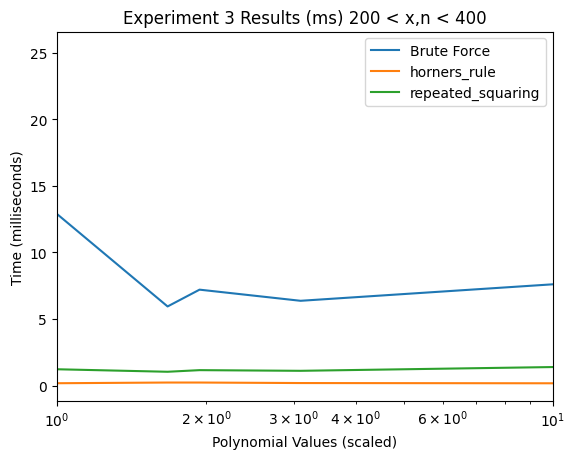

In [18]:
plt.plot(xbf,ex3_brute_force['time_ms'],label='Brute Force')
plt.plot(xhr,ex3_horners_rule['time_ms'],label='horners_rule')
plt.plot(xrs,ex3_repeated_squaring['time_ms'],label='repeated_squaring')
plt.title("Experiment 3 Results (ms) 200 < x,n < 400")
plt.xlabel("Polynomial Values (scaled)")
plt.ylabel("Time (milliseconds)")
plt.legend()
plt.xscale('log')
plt.show()

In [19]:
bf_val = number_to_digits(ex3_values['Brute_Force'].iloc[567])
ha_val = number_to_digits(ex3_values['Horners_Algo'].iloc[567])
rs_val = number_to_digits(ex3_values['Repeated_Sq'].iloc[567])

### Comparing Random Slices

In [20]:
compare_digits(bf_val,ha_val, rs_val)

indices a-b: 646-662

index0: 7 7 7

index1: 0 0 0

index2: 4 4 4

index3: 3 3 3

index4: 1 1 1

index5: 3 3 3

index6: 6 6 6

index7: 5 5 5

index8: 8 8 8

index9: 7 7 7

index10: 1 1 1

index11: 6 6 6

index12: 3 3 3

index13: 1 1 1

index14: 7 7 7

index15: 9 9 9



## Final Results
The pattern established in experiment two held in experiment three. The random digit check held consistantly for randomly generated *a* and *b*.
One thing that surprised me at larger values of x and n was how the gap between Horner's Algorithm and the Repeated Squaring algorithm got smaller, showing how the efficiency of algorithms can change given larger values. 